In [1]:
import numpy as np
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv("train.csv")
train2 = pd.read_csv("training_extra.csv")
test = pd.read_csv("test.csv")
submissions = pd.read_csv("sample_submission.csv")

In [4]:
train.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


In [5]:
train2.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,500000,Under Armour,Canvas,Small,10.0,Yes,Yes,Tote,Blue,23.882052,114.11068
1,500001,Puma,Polyester,Small,4.0,No,Yes,Backpack,Green,11.869095,129.74972
2,500002,Jansport,Polyester,Small,8.0,Yes,Yes,Tote,Red,8.092302,21.37370
3,500003,Nike,Nylon,Large,7.0,No,No,Messenger,Pink,7.719581,48.09209
4,500004,Nike,Leather,Large,9.0,No,Yes,Tote,Green,22.741826,77.32461


In [6]:
print(train2.shape)
print(train.shape)

(3694318, 11)
(300000, 11)


Text(0.5, 1.0, 'Distribution of price')

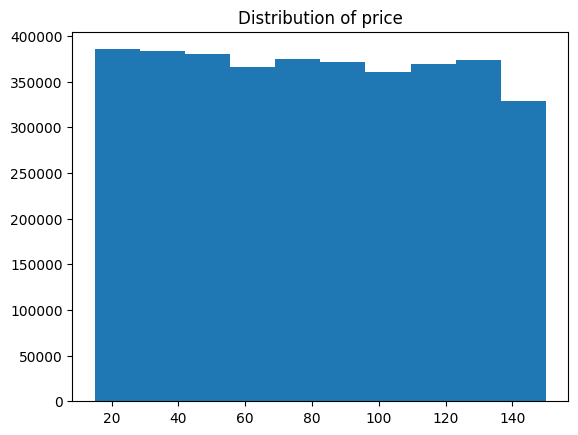

In [7]:
plt.hist(x = train2["Price"])
plt.title("Distribution of price")

In [8]:
train2.isnull().sum()

id                           0
Brand                   117053
Material                102615
Size                     81190
Compartments                 0
Laptop Compartment       91089
Waterproof               87274
Style                    96210
Color                   123667
Weight Capacity (kg)      1670
Price                        0
dtype: int64

Text(0.5, 1.0, 'Distribution of price')

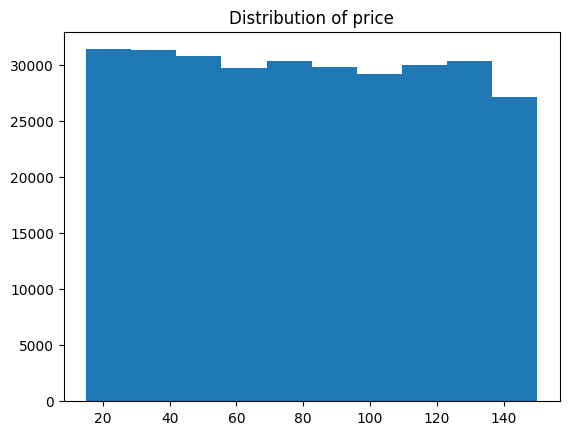

In [9]:
plt.hist(x = train["Price"])
plt.title("Distribution of price")

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB


In [11]:
train.isnull().sum()

id                         0
Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

In [12]:
features_with_na = [feature for feature in train.columns if train[feature].isnull().sum() > 1]
features_with_na

['Brand',
 'Material',
 'Size',
 'Laptop Compartment',
 'Waterproof',
 'Style',
 'Color',
 'Weight Capacity (kg)']

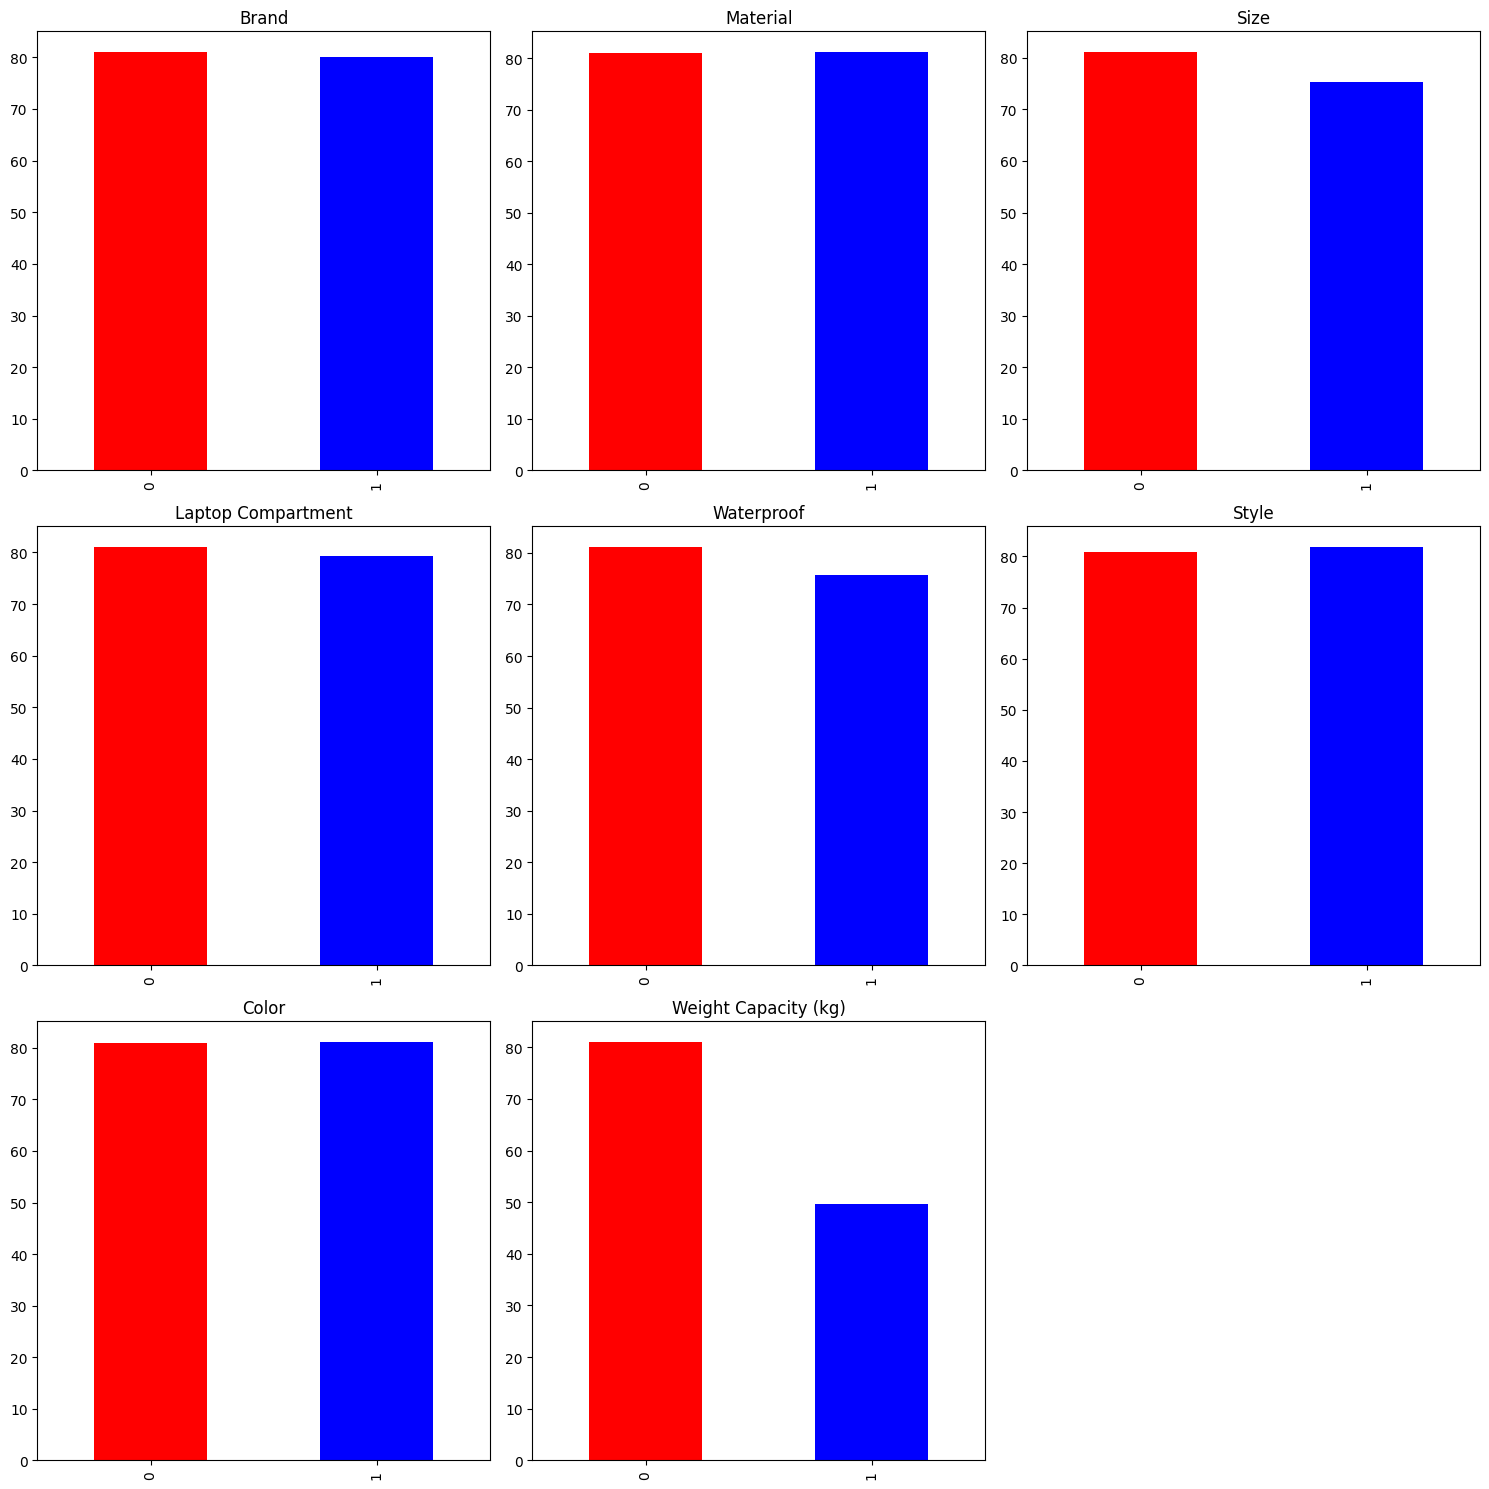

In [13]:
rows=int(np.ceil(len(features_with_na)/3))
col=3
fig, axes=plt.subplots(rows,col,figsize=(15, rows*5))
axes=axes.flatten()

for idx, feature in enumerate(features_with_na):
    data=train.copy()
    data[feature]=np.where(data[feature].isnull(),1,0)
    data.groupby(feature)['Price'].median().plot.bar(ax=axes[idx],color=['red','blue'])
    axes[idx].set_title(feature)
    axes[idx].set_xlabel('') 
for idx in range(len(features_with_na), len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.show()

In [14]:
numerical_feature = [feature for feature in train.columns if train[feature].dtype != "O"]
print("Numerical Features of data are:", numerical_feature)

Numerical Features of data are: ['id', 'Compartments', 'Weight Capacity (kg)', 'Price']


Text(0.5, 1.0, 'Average weights of bagpack based on brands')

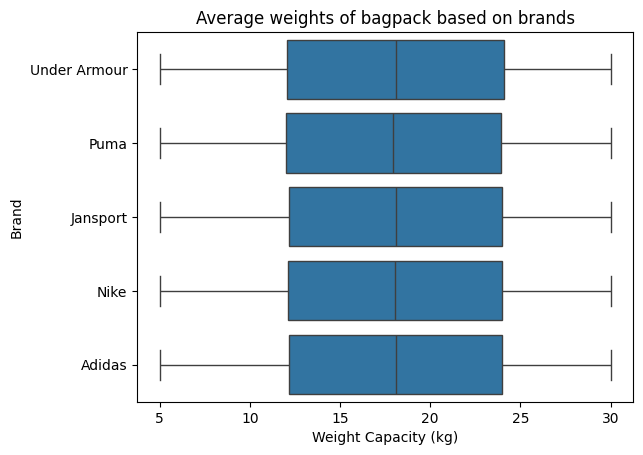

In [15]:
sns.boxplot(x = "Weight Capacity (kg)", y = "Brand", data = train2)
plt.title("Average weights of bagpack based on brands")

In [16]:
train["Weight Capacity (kg)"] = train["Weight Capacity (kg)"].fillna(train["Weight Capacity (kg)"].median())
train2["Weight Capacity (kg)"] = train2["Weight Capacity (kg)"].fillna(train["Weight Capacity (kg)"].median())

In [17]:
categorical_features = [feature for feature in train.columns if train[feature].dtype == "O"]
categorical_features

['Brand',
 'Material',
 'Size',
 'Laptop Compartment',
 'Waterproof',
 'Style',
 'Color']

In [18]:
train_len = len(train)
train_merge = pd.concat([train, train2], axis=0, ignore_index=False)

In [19]:
train_merge.isnull().sum()

id                           0
Brand                   126758
Material                110962
Size                     87785
Compartments                 0
Laptop Compartment       98533
Waterproof               94324
Style                   104180
Color                   133617
Weight Capacity (kg)         0
Price                        0
dtype: int64

ValueError: cannot reindex on an axis with duplicate labels

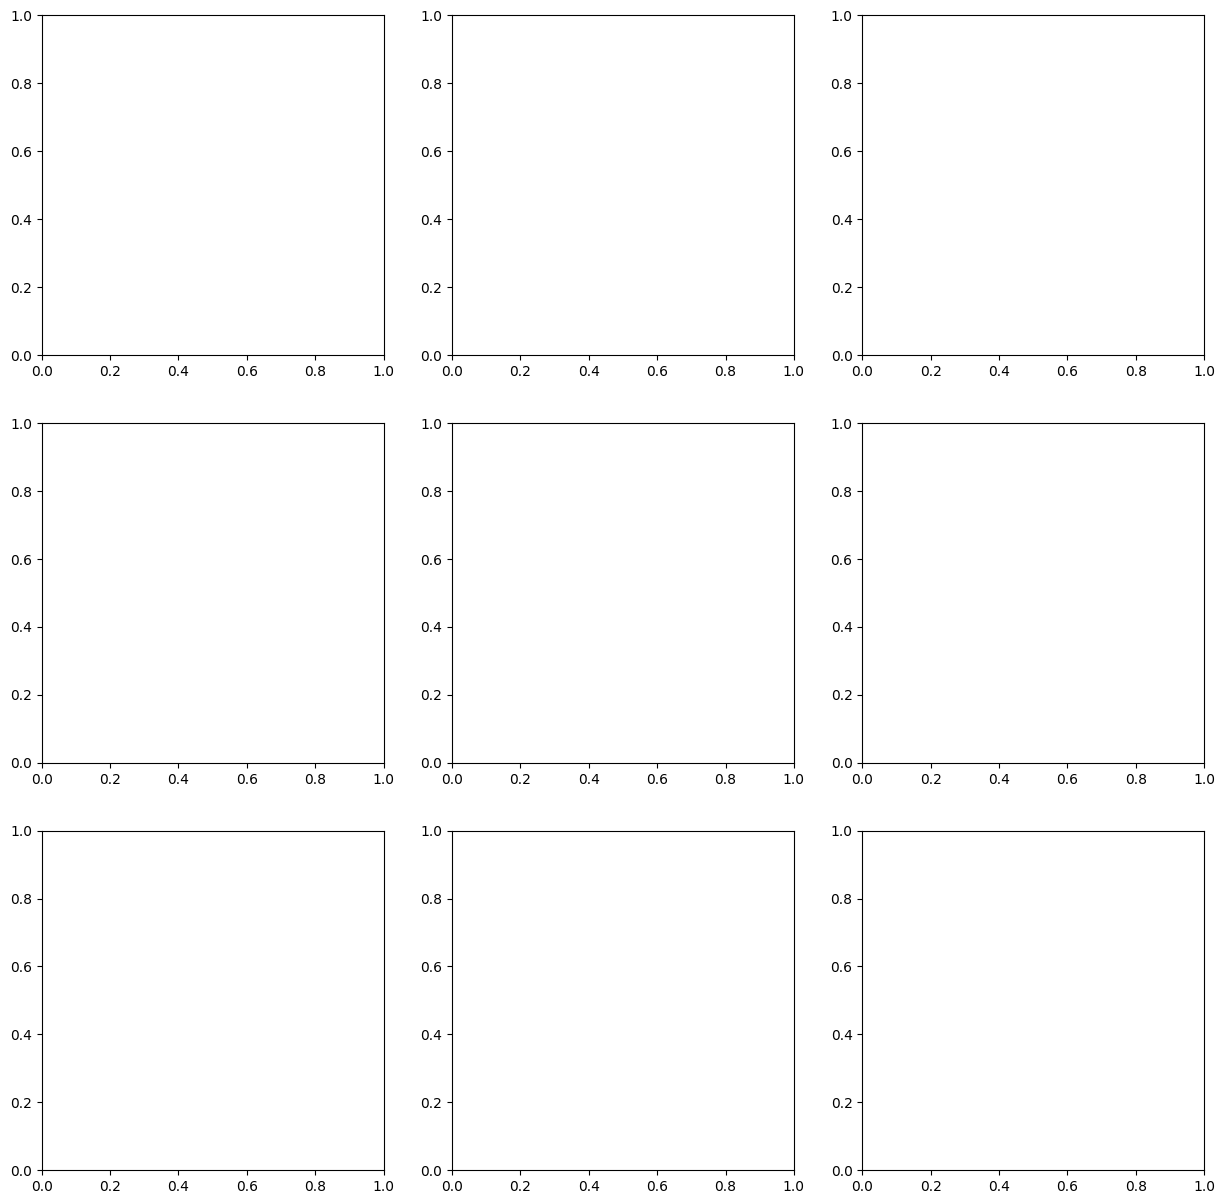

In [20]:
rows = int(np.ceil(len(categorical_features) / 3))
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    if feature in train_merge.columns:
        sns.countplot(x=feature, data=train_merge, ax=axes[idx])
        axes[idx].set_title(feature)
        axes[idx].set_xlabel('')
    else:
        axes[idx].set_visible(False)  # Hide the subplot if feature is missing

# Remove extra subplots
for idx in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="constant", fill_value="Unknown")

In [22]:
train_merge[categorical_features] = imputer.fit_transform(train_merge[categorical_features])
print(train_merge.isnull().sum())

id                      0
Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
Price                   0
dtype: int64


In [23]:
test["Weight Capacity (kg)"] = test["Weight Capacity (kg)"].fillna(test["Weight Capacity (kg)"].median())
test[categorical_features] = imputer.transform(test[categorical_features])
test.isnull().sum()

id                      0
Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
dtype: int64

In [24]:
size_mapping = {
    "Unknown": 0,
    "Small": 1,
    "Medium": 2,
    "Large": 3
}

train_merge["Size"] = train_merge["Size"].replace(size_mapping)
test["Size"] = test["Size"].replace(size_mapping)

In [25]:
def encode_binary_with_unknown(column):
    return column.map({"Yes": 1, "No": 0, "Unknown": 2})

train_merge["Laptop Compartment"] = encode_binary_with_unknown(train_merge["Laptop Compartment"])
train_merge["Waterproof"] = encode_binary_with_unknown(train_merge["Waterproof"])
test["Laptop Compartment"] = encode_binary_with_unknown(test["Laptop Compartment"])
test["Waterproof"] = encode_binary_with_unknown(test["Waterproof"])

In [26]:
train_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3994318 entries, 0 to 3694317
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Brand                 object 
 2   Material              object 
 3   Size                  int64  
 4   Compartments          float64
 5   Laptop Compartment    int64  
 6   Waterproof            int64  
 7   Style                 object 
 8   Color                 object 
 9   Weight Capacity (kg)  float64
 10  Price                 float64
dtypes: float64(3), int64(4), object(4)
memory usage: 365.7+ MB


In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ["Brand", "Material", "Style", "Color"]

for feature in cat_cols:
    train_merge[feature] = le.fit_transform(train_merge[feature])
    test[feature] = le.transform(test[feature])

In [28]:
test.drop(["id"], inplace = True, axis = 1)

In [29]:
y = train_merge["Price"]
train_merge.drop(["Price", "id"], inplace = True, axis = 1)

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

feature_scale = [feature for feature in train_merge if feature not in ["id", "Price"]]

In [32]:
scaler.fit(train_merge[feature_scale])
train_scaled = pd.concat([pd.DataFrame(scaler.transform(train_merge[feature_scale]), columns=feature_scale)],
                        axis=1)
train_scaled.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,0.2,0.25,0.666667,0.666667,0.5,0.0,0.666667,0.000000,0.264469
1,0.2,0.00,0.333333,1.000000,0.5,0.5,0.333333,0.500000,0.883141
2,0.8,0.25,0.333333,0.111111,0.5,0.0,0.333333,0.833333,0.465750
3,0.4,0.50,0.333333,0.777778,0.5,0.0,0.333333,0.500000,0.317489
4,0.0,0.00,0.666667,0.000000,0.5,0.5,0.333333,0.500000,0.509974


In [33]:
test_scaled = pd.concat([pd.DataFrame(scaler.transform(test[feature_scale]), columns=feature_scale)],
                       axis=1)
test_scaled.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,0.6,0.25,0.333333,0.111111,0.0,0.0,0.666667,0.500000,0.626846
1,0.4,0.00,0.666667,0.666667,0.0,0.5,0.000000,0.500000,0.342564
2,0.0,0.00,1.000000,0.888889,0.0,0.5,0.333333,0.166667,0.272392
3,0.0,0.50,1.000000,0.000000,0.5,0.0,0.333333,0.500000,0.539081
4,1.0,0.50,1.000000,0.111111,0.5,0.5,0.666667,0.000000,0.196318


In [38]:
from sklearn.model_selection import train_test_split, cross_val_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

In [39]:
X_train, X_test, y_train, y_test = train_test_split(train_scaled, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f"Linear Regression MSE: {mse_lr}")
rmse = mse_lr ** 0.5
print("RMSE:", rmse)

Linear Regression MSE: 1513.7587421490687
RMSE: 38.907052601669385


In [42]:
model_xgb = XGBRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 6, random_state = 42)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"RMSE Score:, {rmse:.4f}")

RMSE Score:, 38.8535
